In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:

df = pd.read_csv("HR_employee_retention.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
df.shape

(1470, 35)

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [6]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [8]:
#target variable
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

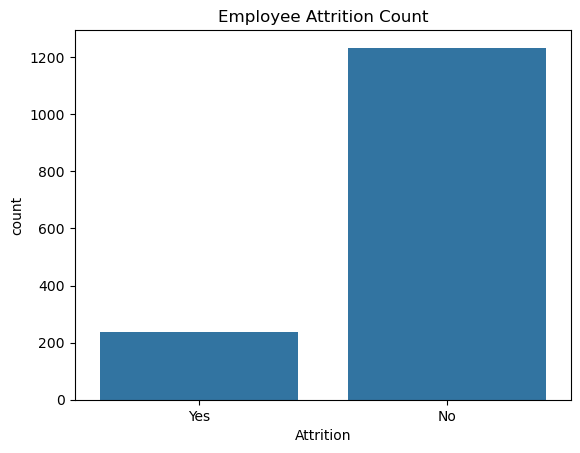

In [9]:
sns.countplot(x="Attrition", data=df)

plt.title("Employee Attrition Count")
plt.show()

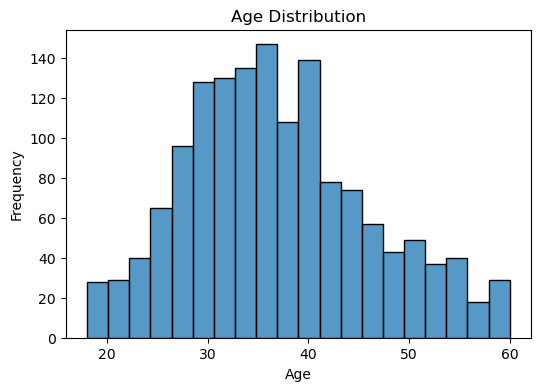

In [10]:
#age distribution
plt.figure(figsize=(6,4))
sns.histplot(df["Age"], bins=20, kde=False)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

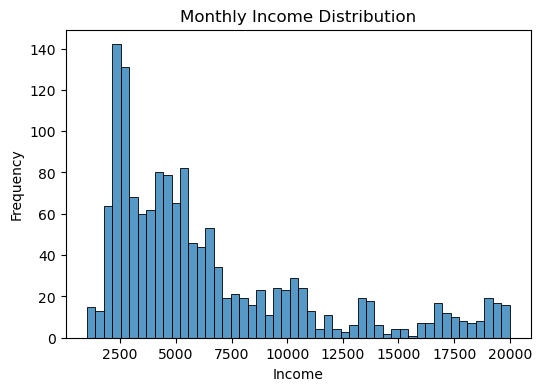

In [11]:
#monthly income distribution
plt.figure(figsize=(6,4))
sns.histplot(df["MonthlyIncome"], bins=50, kde=False)
plt.title("Monthly Income Distribution")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

In [12]:
#konse umar k log zyada nikal rahe hain ?

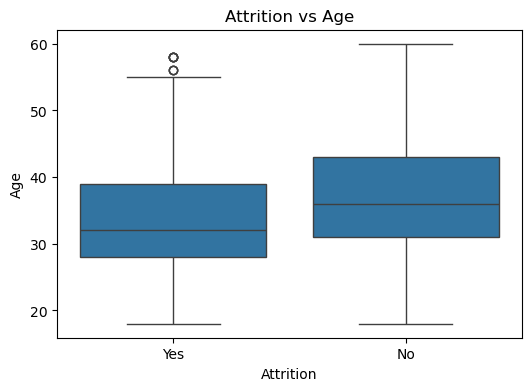

In [13]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Attrition", y="Age", data=df)
plt.title("Attrition vs Age")
plt.show()

### Younger employees may leave more frequently

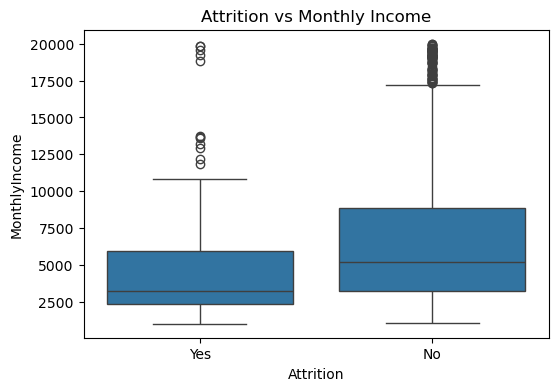

In [14]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Attrition", y="MonthlyIncome", data=df)
plt.title("Attrition vs Monthly Income")
plt.show()

## Employees with lower income tend to leave more(main factor lag raha hai)

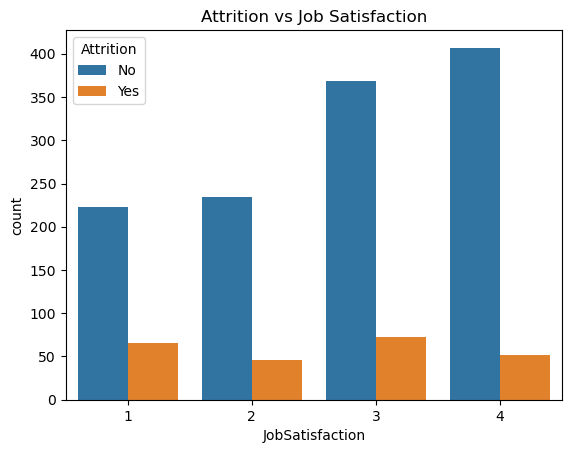

In [15]:
sns.countplot(x="JobSatisfaction", hue="Attrition", data=df)
plt.title("Attrition vs Job Satisfaction")
plt.show()

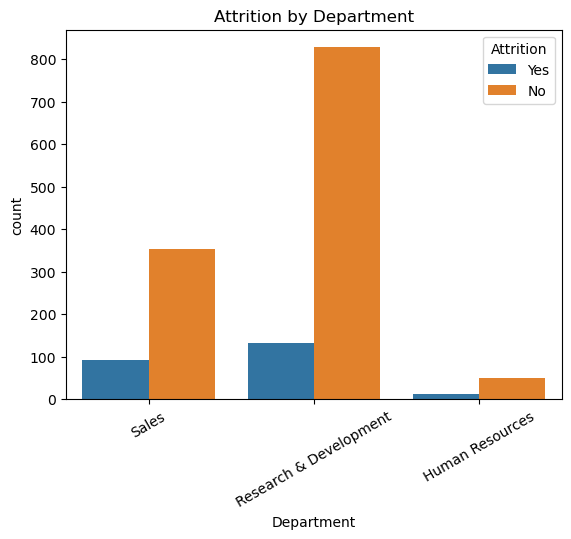

In [16]:
sns.countplot(x="Department", hue="Attrition", data=df)
plt.title("Attrition by Department")
plt.xticks(rotation=30)
plt.show()

In [17]:
df["Department"].value_counts()

Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

### we see Research department have more leaving rate on comparison to other departments.

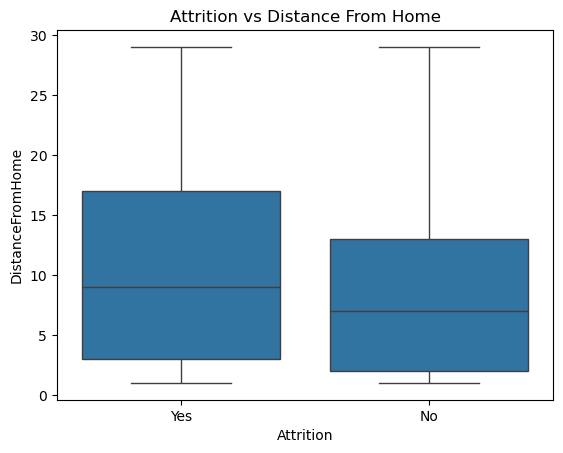

In [18]:
sns.boxplot(x="Attrition", y="DistanceFromHome", data=df)
plt.title("Attrition vs Distance From Home")
plt.show()

### employee residing far away tends to leave more !


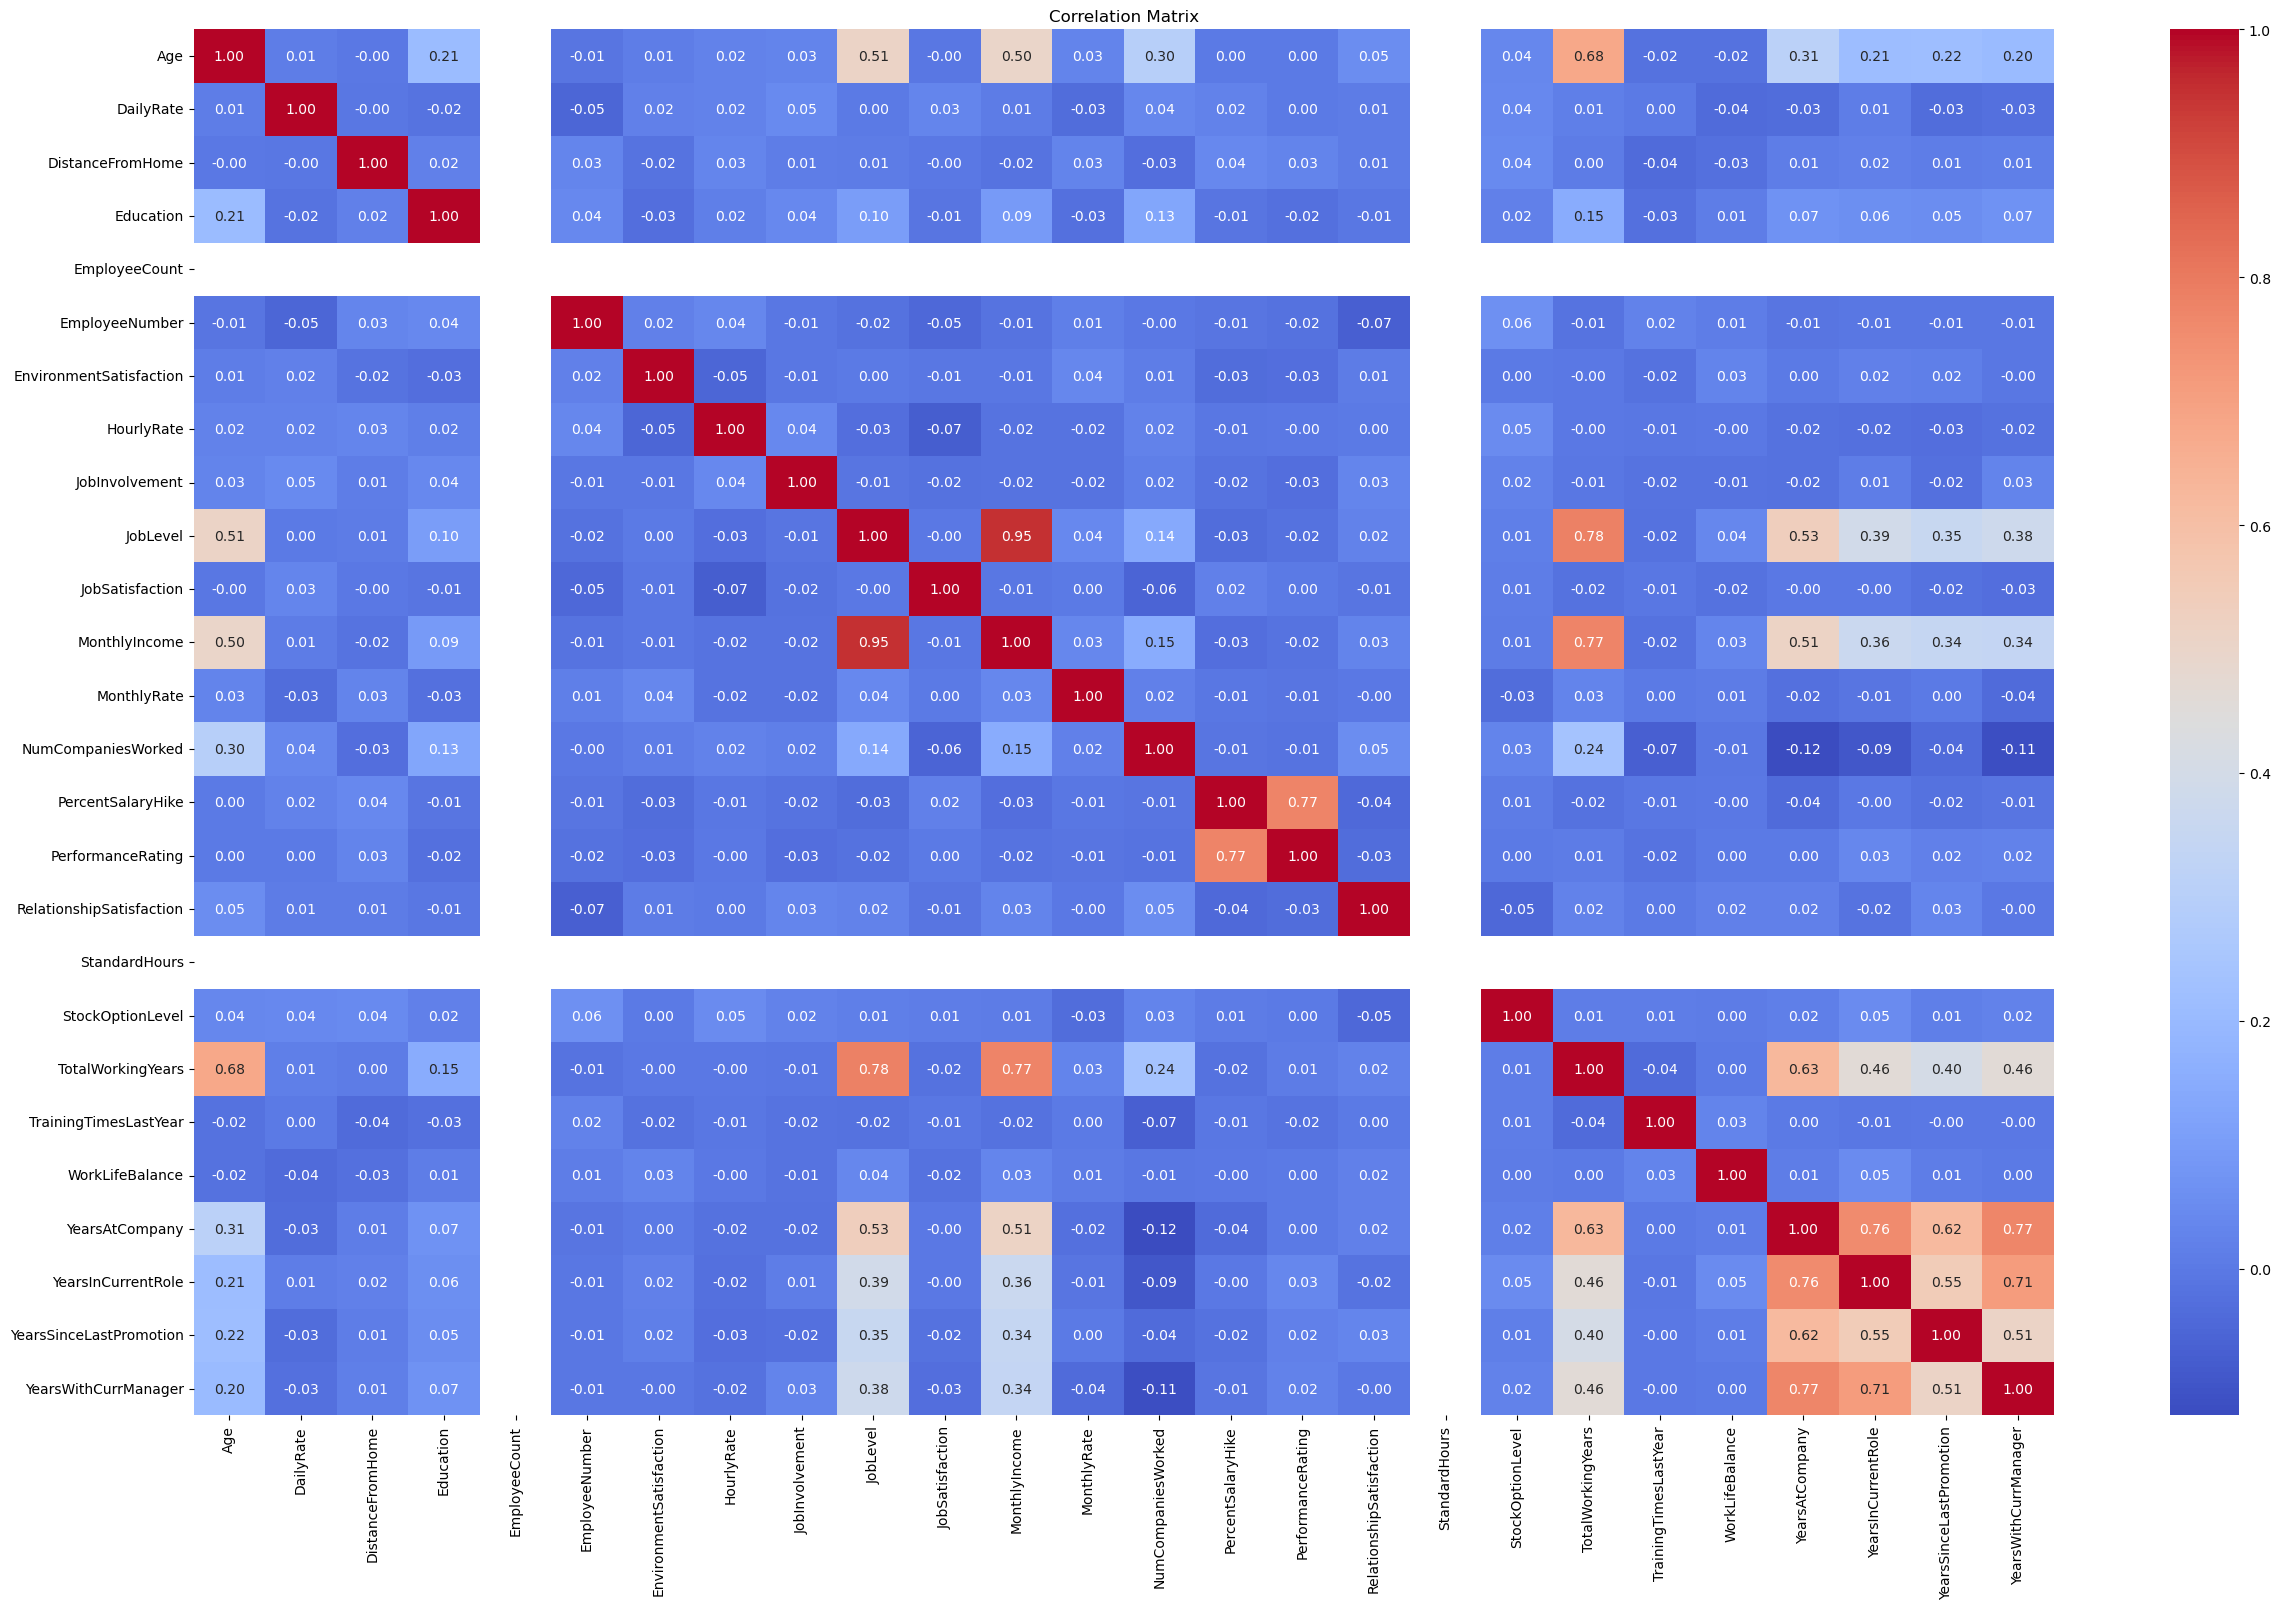

In [19]:
corr = df.corr(numeric_only=True,)
plt.figure(figsize=(30,18))
sns.heatmap(corr, cmap="coolwarm",annot = True,fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [20]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [21]:
# 1. Drop colums with constant values or useless data that can harm the model training.
drop_cols = ["EmployeeCount", "EmployeeNumber", "Over18", "StandardHours"]
for col in drop_cols:
    if col in df.columns:
        del df[col]# (instead of drop inplace =true we did this way becuz it will return none to df which cause error in select_dtypes)

In [22]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

In [23]:
#Feature engineering
# Identify columns
num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(include=["object"]).columns
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])



In [24]:
# 1. Income per experience year
if "MonthlyIncome" in df.columns and "TotalWorkingYears" in df.columns:
    df['IncomePerExperience'] = df['MonthlyIncome'] / (df['TotalWorkingYears'] + 1)

# 2. Income per job level
if "MonthlyIncome" in df.columns and "JobLevel" in df.columns:
    df['IncomePerLevel'] = df['MonthlyIncome'] / df['JobLevel']

# 3. Loyalty ratio
if "YearsAtCompany" in df.columns and "TotalWorkingYears" in df.columns:
    df['CompanyLoyaltyRatio'] = df['YearsAtCompany'] / (df['TotalWorkingYears'] + 1)

# 4. Promotion rate
if "YearsSinceLastPromotion" in df.columns and "YearsAtCompany" in df.columns:
    df['PromotionRate'] = df['YearsSinceLastPromotion'] / (df['YearsAtCompany'] + 1)

# 5. Tenure group (CREATE BEFORE DROPPING)
if "YearsAtCompany" in df.columns:
    df['tenure_group'] = pd.cut(
        df['YearsAtCompany'],
        bins=[0, 2, 5, 10, 40],
        labels=[0, 1, 2, 3]
    )



df.drop(['MonthlyIncome', 'TotalWorkingYears', 'JobLevel', 'YearsSinceLastPromotion'], 
        axis=1, inplace=True, errors='ignore')

In [25]:
df["Attrition"] = df["Attrition"].map({"Yes":1, "No":0})
df["Attrition"].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

In [26]:
# Encode categorical variables
df = pd.get_dummies(df, drop_first=True)

In [27]:
df.head(20)

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobSatisfaction,MonthlyRate,...,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes,tenure_group_1,tenure_group_2,tenure_group_3
0,41.0,1,1102.0,1.0,2.0,2.0,94.0,3.0,4.0,19479.0,...,False,False,True,False,False,True,True,False,True,False
1,49.0,0,279.0,8.0,1.0,3.0,61.0,2.0,2.0,24907.0,...,False,True,False,False,True,False,False,False,True,False
2,37.0,1,1373.0,2.0,2.0,4.0,92.0,2.0,3.0,2396.0,...,False,False,False,False,False,True,True,False,False,False
3,33.0,0,1392.0,3.0,4.0,4.0,56.0,3.0,3.0,23159.0,...,False,True,False,False,True,False,True,False,True,False
4,27.0,0,591.0,2.0,1.0,1.0,40.0,3.0,2.0,16632.0,...,False,False,False,False,True,False,False,False,False,False
5,32.0,0,1005.0,2.0,2.0,4.0,79.0,3.0,4.0,11864.0,...,False,False,False,False,False,True,False,False,True,False
6,59.0,0,1324.0,3.0,3.0,3.0,81.0,4.0,1.0,9964.0,...,False,False,False,False,True,False,True,False,False,False
7,30.0,0,1358.0,24.0,1.0,4.0,67.0,3.0,3.0,13335.0,...,False,False,False,False,False,False,False,False,False,False
8,38.0,0,216.0,23.0,3.0,4.0,44.0,2.0,3.0,8787.0,...,False,False,False,False,False,True,False,False,True,False
9,36.0,0,1299.0,27.0,3.0,3.0,94.0,3.0,3.0,16577.0,...,False,False,False,False,True,False,False,False,True,False


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 48 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                1470 non-null   float64
 1   Attrition                          1470 non-null   int64  
 2   DailyRate                          1470 non-null   float64
 3   DistanceFromHome                   1470 non-null   float64
 4   Education                          1470 non-null   float64
 5   EnvironmentSatisfaction            1470 non-null   float64
 6   HourlyRate                         1470 non-null   float64
 7   JobInvolvement                     1470 non-null   float64
 8   JobSatisfaction                    1470 non-null   float64
 9   MonthlyRate                        1470 non-null   float64
 10  NumCompaniesWorked                 1470 non-null   float64
 11  PercentSalaryHike                  1470 non-null   float

In [29]:
# Define target variable
y = df["Attrition"]

# Define features
X = df.drop("Attrition", axis=1)

print("Feature matrix shape:", X.shape)

Feature matrix shape: (1470, 47)


In [30]:
# Numerical features
num_cols = X.select_dtypes(include=["int64","float64"]).columns

# Categorical features
cat_cols = X.select_dtypes(include=["bool"]).columns

print("Numerical Columns:")
print(list(num_cols))


print("\nCategorical Columns:")
print(list(cat_cols))


Numerical Columns:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobSatisfaction', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsWithCurrManager', 'IncomePerExperience', 'IncomePerLevel', 'CompanyLoyaltyRatio', 'PromotionRate']

Categorical Columns:
['BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely', 'Department_Research & Development', 'Department_Sales', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree', 'Gender_Male', 'JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRole_Manufacturing Director', 'JobRole_Research Director', 'JobRole_Research Scientist', 'JobRole_Sales Executive', 'JobRole_Sales Representat

In [31]:
print(X.columns.tolist())

['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobSatisfaction', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsWithCurrManager', 'IncomePerExperience', 'IncomePerLevel', 'CompanyLoyaltyRatio', 'PromotionRate', 'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely', 'Department_Research & Development', 'Department_Sales', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree', 'Gender_Male', 'JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRole_Manufacturing Director', 'JobRole_Research Director', 'JobRole_Research Scientist', 'JobRole_Sales Executive', 'JobRole_Sales Representative', 'MaritalStatus_Married', 'MaritalSta

In [32]:
# Ordinal categorical variables
ordinal_cols = ["Education","JobSatisfaction"]

# Nominal categorical variables
nominal_cols = [col for col in cat_cols if col not in ordinal_cols]

print("Ordinal columns:", ordinal_cols)
print("Nominal columns:", nominal_cols)

Ordinal columns: ['Education', 'JobSatisfaction']
Nominal columns: ['BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely', 'Department_Research & Development', 'Department_Sales', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree', 'Gender_Male', 'JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRole_Manufacturing Director', 'JobRole_Research Director', 'JobRole_Research Scientist', 'JobRole_Sales Executive', 'JobRole_Sales Representative', 'MaritalStatus_Married', 'MaritalStatus_Single', 'OverTime_Yes', 'tenure_group_1', 'tenure_group_2', 'tenure_group_3']


In [33]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

Training shape: (1176, 47)
Test shape: (294, 47)


In [35]:
nominal_encoder = OneHotEncoder(
    drop="first",
    handle_unknown="ignore",
    sparse_output=False   # was 'sparse' in older versions
)

In [36]:
ordinal_encoder = OrdinalEncoder()
num_scaler = StandardScaler()

In [37]:
# Numerical pipeline
num_pipeline = Pipeline([
    ("scaler", num_scaler)
])

# Ordinal categorical pipeline
ordinal_pipeline = Pipeline([
    ("encoder", ordinal_encoder)
])

# Nominal categorical pipeline
nominal_pipeline = Pipeline([
    ("encoder", nominal_encoder)
])

In [38]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, num_cols),
        ("ordinal", ordinal_pipeline, ordinal_cols),
        ("nominal", nominal_pipeline, nominal_cols)
    ]
)

In [39]:
# import joblib

# # Save full preprocessing pipeline
# joblib.dump(preprocessor, "preprocessor.pkl")

# print("✅ Preprocessor (all encoders + scaler) saved successfully!")

✅ Preprocessor (all encoders + scaler) saved successfully!


In [40]:
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)
y_train_transformed = preprocessor.fit_transform(X_train)
y_test_transformed = preprocessor.transform(X_test)

In [57]:
# NOW save it (after fitting)
joblib.dump(preprocessor, "preprocessor.pkl")
print("✅ Fitted preprocessor saved!")

✅ Fitted preprocessor saved!


In [41]:
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier

from sklearn.linear_model import LogisticRegression
# Ensemble methods
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                              AdaBoostClassifier, BaggingClassifier, VotingClassifier)

# Support Vector Machine
from sklearn.svm import SVC

# Nearest Neighbors
from sklearn.neighbors import KNeighborsClassifier

# Naive Bayes
from sklearn.naive_bayes import GaussianNB

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

In [42]:
dummy = DummyClassifier(strategy="most_frequent")

dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)

print("Dummy Accuracy:", accuracy_score(y_test, y_pred_dummy))
print(classification_report(y_test, y_pred_dummy))

Dummy Accuracy: 0.8401360544217688
              precision    recall  f1-score   support

           0       0.84      1.00      0.91       247
           1       0.00      0.00      0.00        47

    accuracy                           0.84       294
   macro avg       0.42      0.50      0.46       294
weighted avg       0.71      0.84      0.77       294



In [43]:
log_model = LogisticRegression(max_iter=2000)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

y_prob_log = log_model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))
print("ROC AUC:", roc_auc_score(y_test, y_prob_log))
print("Fbeta_score: ",fbeta_score(y_test, y_pred_log,beta = 1))

print(classification_report(y_test, y_pred_log))

Accuracy: 0.8605442176870748
Precision: 0.65
Recall: 0.2765957446808511
F1 Score: 0.3880597014925373
ROC AUC: 0.7572573003704023
Fbeta_score:  0.3880597014925373
              precision    recall  f1-score   support

           0       0.88      0.97      0.92       247
           1       0.65      0.28      0.39        47

    accuracy                           0.86       294
   macro avg       0.76      0.62      0.65       294
weighted avg       0.84      0.86      0.84       294



In [44]:
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
models = {

    "Random_Forest": RandomForestClassifier(random_state=42, class_weight='balanced'),

    "Gradient Boosting": GradientBoostingClassifier(),

    "SVM": SVC(probability=True, class_weight='balanced'),

    "KNN": KNeighborsClassifier(),

    "Abc": AdaBoostClassifier(),

    "Bc": BaggingClassifier(),

    "Vc": VotingClassifier(
        estimators=[
            ('rf', RandomForestClassifier(class_weight='balanced')),
            ('svc', SVC(probability=True))
        ],
        voting='soft'
    ),

    "GaussianNB": GaussianNB(),

  

    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=3,   
        random_state=42,
        eval_metric='logloss'
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=-1,       
        class_weight='balanced',
        random_state=42
    )
}

In [45]:

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    results.append([name, acc, prec, rec, f1, roc])

results_df = pd.DataFrame(results,
                          columns=["Model","Accuracy","Precision","Recall","F1","ROC_AUC"])

results_df.sort_values("F1", ascending=False)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 190, number of negative: 986
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000659 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1483
[LightGBM] [Info] Number of data points in the train set: 1176, number of used features: 46
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
7,GaussianNB,0.775510,0.369863,0.574468,0.450000,0.725816
9,LightGBM,0.846939,0.541667,0.276596,0.366197,0.739512
8,XGBoost,0.850340,0.571429,0.255319,0.352941,0.764235
4,Abc,0.860544,0.714286,0.212766,0.327869,0.763632
1,Gradient Boosting,0.843537,0.523810,0.234043,0.323529,0.772590
2,SVM,0.564626,0.176000,0.468085,0.255814,0.527522
5,Bc,0.812925,0.250000,0.085106,0.126984,0.659790
0,Random_Forest,0.840136,0.500000,0.063830,0.113208,0.738608
3,KNN,0.826531,0.250000,0.042553,0.072727,0.573521
6,Vc,0.843537,1.000000,0.021277,0.041667,0.722974


In [46]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

model = XGBClassifier(
    n_estimators=350,
    learning_rate=0.15,
    max_depth=3,
    subsample=0.7,
    colsample_bytree=0.6,
    scale_pos_weight=4.5,
    random_state=42,
    min_child_weight=10,   # avoid tiny groups
    gamma=1,               # only useful splits
    reg_alpha=0.5,         # remove weak features
    reg_lambda=1, 
    eval_metric='logloss'
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.8231292517006803
Precision: 0.43902439024390244
Recall: 0.3829787234042553
F1: 0.4090909090909091
ROC AUC: 0.7694891894220002


In [47]:
from lightgbm import LGBMClassifier

model = LGBMClassifier(
    n_estimators=350,
    learning_rate=0.05,
    num_leaves=50,
    max_depth=3,
    min_child_samples=15,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=0.5,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 190, number of negative: 986
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000627 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1483
[LightGBM] [Info] Number of data points in the train set: 1176, number of used features: 46
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

In [48]:

import numpy as np
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', LGBMClassifier(
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1
    ))
])


param_grid = {
    'model__n_estimators': [200, 400, 600, 800],
    'model__learning_rate': [0.03, 0.05, 0.1],
    'model__num_leaves': [31, 50, 80],
    'model__max_depth': [-1, 5, 10],
    'model__min_child_samples': [10, 20, 50],
    'model__subsample': [0.7, 0.8, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 1.0],
    'model__reg_alpha': [0, 0.1, 1],
    'model__reg_lambda': [0, 0.1, 1]
}


random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_grid,
    n_iter=30,
    scoring='f1',
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)


random_search.fit(X_train, y_train)

print("\nBest Params:", random_search.best_params_)
print("Best CV F1 Score:", round(random_search.best_score_, 4))

best_model = random_search.best_estimator_


y_prob = best_model.predict_proba(X_test)[:, 1]


best_f1 = 0
best_t = 0

for t in np.arange(0.1, 0.6, 0.01):
    y_pred = (y_prob >= t).astype(int)
    
    f1 = f1_score(y_test, y_pred)
    
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("\nBest Threshold:", round(best_t, 2))
print("Best F1:", round(best_f1, 4))


y_pred_final = (y_prob >= best_t).astype(int)

print("\n--- Final Test Performance ---")
print("Accuracy :", round(accuracy_score(y_test, y_pred_final), 4))
print("Precision:", round(precision_score(y_test, y_pred_final), 4))
print("Recall   :", round(recall_score(y_test, y_pred_final), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_final), 4))
print("ROC AUC  :", round(roc_auc_score(y_test, y_prob), 4))

Fitting 3 folds for each of 30 candidates, totalling 90 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 986, number of negative: 986
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009165 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5651
[LightGBM] [Info] Number of data points in the train set: 1972, number of used features: 46
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positi

In [49]:
for t in [0.1, 0.2, 0.3, 0.4, 0.5]:
    y_pred = (y_prob >= t).astype(int)
    
    print(f"\nThreshold: {t}")
    print("Accuracy :", round(accuracy_score(y_test, y_pred_final), 4))
    print("Precision:", round(precision_score(y_test, y_pred_final), 4))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1:", f1_score(y_test, y_pred))


Threshold: 0.1
Accuracy : 0.8367
Precision: 0.4902
Recall: 0.7659574468085106
F1: 0.43902439024390244

Threshold: 0.2
Accuracy : 0.8367
Precision: 0.4902
Recall: 0.6170212765957447
F1: 0.4566929133858268

Threshold: 0.3
Accuracy : 0.8367
Precision: 0.4902
Recall: 0.5531914893617021
F1: 0.5

Threshold: 0.4
Accuracy : 0.8367
Precision: 0.4902
Recall: 0.44680851063829785
F1: 0.4883720930232558

Threshold: 0.5
Accuracy : 0.8367
Precision: 0.4902
Recall: 0.3829787234042553
F1: 0.4444444444444444


In [50]:

import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE


scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])


pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1,
        use_label_encoder=False,
        eval_metric='logloss'
    ))
])


param_grid = {
    'model__n_estimators': [200, 400, 600, 800],
    'model__learning_rate': [0.03, 0.05, 0.1],
    'model__max_depth': [3, 5, 8, 10],
    'model__min_child_weight': [1, 3, 5, 7],
    'model__subsample': [0.7, 0.8, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 1.0],
    'model__gamma': [0, 0.1, 0.3],
    'model__reg_alpha': [0, 0.1, 1],
    'model__reg_lambda': [0, 0.1, 1]
}


random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_grid,
    n_iter=30,
    scoring='f1',
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)


random_search.fit(X_train, y_train)

print("\nBest Params:", random_search.best_params_)
print("Best CV F1 Score:", round(random_search.best_score_, 4))

best_model_xg = random_search.best_estimator_


y_prob = best_model.predict_proba(X_test)[:, 1]


best_f1 = 0
best_t = 0

for t in np.arange(0.1, 0.6, 0.01):
    y_pred = (y_prob >= t).astype(int)
    
    f1 = f1_score(y_test, y_pred)
    
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("\nBest Threshold:", round(best_t, 2))
print("Best F1:", round(best_f1, 4))


y_pred_final = (y_prob >= best_t).astype(int)

print("\n--- Final Test Performance ---")
print("Accuracy :", round(accuracy_score(y_test, y_pred_final), 4))
print("Precision:", round(precision_score(y_test, y_pred_final), 4))
print("Recall   :", round(recall_score(y_test, y_pred_final), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_final), 4))
print("ROC AUC  :", round(roc_auc_score(y_test, y_prob), 4))

Fitting 3 folds for each of 30 candidates, totalling 90 fits

Best Params: {'model__subsample': 0.8, 'model__reg_lambda': 1, 'model__reg_alpha': 1, 'model__n_estimators': 400, 'model__min_child_weight': 1, 'model__max_depth': 8, 'model__learning_rate': 0.03, 'model__gamma': 0.3, 'model__colsample_bytree': 0.7}
Best CV F1 Score: 0.5384

Best Threshold: 0.32
Best F1: 0.5102

--- Final Test Performance ---
Accuracy : 0.8367
Precision: 0.4902
Recall   : 0.5319
F1 Score : 0.5102
ROC AUC  : 0.7713


In [51]:
for t in [0.1, 0.2, 0.3, 0.4, 0.5]:
    y_pred = (y_prob >= t).astype(int)
    
    print(f"\nThreshold: {t}")
    print("Accuracy :", round(accuracy_score(y_test, y_pred_final), 4))
    print("Precision:", round(precision_score(y_test, y_pred_final), 4))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1:", f1_score(y_test, y_pred))


Threshold: 0.1
Accuracy : 0.8367
Precision: 0.4902
Recall: 0.7659574468085106
F1: 0.43902439024390244

Threshold: 0.2
Accuracy : 0.8367
Precision: 0.4902
Recall: 0.6170212765957447
F1: 0.4566929133858268

Threshold: 0.3
Accuracy : 0.8367
Precision: 0.4902
Recall: 0.5531914893617021
F1: 0.5

Threshold: 0.4
Accuracy : 0.8367
Precision: 0.4902
Recall: 0.44680851063829785
F1: 0.4883720930232558

Threshold: 0.5
Accuracy : 0.8367
Precision: 0.4902
Recall: 0.3829787234042553
F1: 0.4444444444444444


In [52]:

import numpy as np
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE


pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', GaussianNB())
])


param_grid = {
    'model__var_smoothing': np.logspace(-11, -7, 10)
}


random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_grid,
    n_iter=10,
    scoring='f1',
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

print("\nBest Params:", random_search.best_params_)
print("Best CV F1 Score:", round(random_search.best_score_, 4))

best_model = random_search.best_estimator_

y_prob = best_model.predict_proba(X_test)[:, 1]


best_f1 = 0
best_t = 0

for t in np.arange(0.1, 0.6, 0.01):
    y_pred = (y_prob >= t).astype(int)
    
    f1 = f1_score(y_test, y_pred)
    
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("\nBest Threshold:", round(best_t, 2))
print("Best F1:", round(best_f1, 4))


y_pred_final = (y_prob >= best_t).astype(int)

print("\n--- Final Test Performance ---")
print("Accuracy :", round(accuracy_score(y_test, y_pred_final), 4))
print("Precision:", round(precision_score(y_test, y_pred_final), 4))
print("Recall   :", round(recall_score(y_test, y_pred_final), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_final), 4))
print("ROC AUC  :", round(roc_auc_score(y_test, y_prob), 4))

Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best Params: {'model__var_smoothing': np.float64(1.6681005372000556e-09)}
Best CV F1 Score: 0.489

Best Threshold: 0.51
Best F1: 0.4874

--- Final Test Performance ---
Accuracy : 0.7925
Precision: 0.4028
Recall   : 0.617
F1 Score : 0.4874
ROC AUC  : 0.7386


In [53]:

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np


lgbm = LGBMClassifier(
    n_estimators=350,
    learning_rate=0.05,
    num_leaves=50,
    max_depth=3,
    class_weight='balanced'
)

xgb = XGBClassifier(
    n_estimators=350,
    learning_rate=0.05,
    max_depth=3,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    use_label_encoder=False
)

# 3. Stacking Model
estimators = [
    ('lgbm', lgbm),
    ('xgb', xgb)
]

stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    stack_method='predict_proba',
    n_jobs=-1
)


stack_model.fit(X_train, y_train)


y_prob = stack_model.predict_proba(X_test)[:, 1]


best_f1 = 0
best_t = 0

for t in np.linspace(0.1, 0.5, 50):
    y_pred = (y_prob >= t).astype(int)
    f1 = f1_score(y_test, y_pred)

    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Best Threshold:", best_t)
print("Best F1:", best_f1)


y_pred_final = (y_prob >= best_t).astype(int)

print("Accuracy :", accuracy_score(y_test, y_pred_final))
print("Precision:", precision_score(y_test, y_pred_final))
print("Recall   :", recall_score(y_test, y_pred_final))
print("F1 Score :", f1_score(y_test, y_pred_final))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

Best Threshold: 0.28775510204081634
Best F1: 0.48936170212765956
Accuracy : 0.8367346938775511
Precision: 0.48936170212765956
Recall   : 0.48936170212765956
F1 Score : 0.48936170212765956
ROC AUC  : 0.7649237660435869


In [54]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_xgb = CalibratedClassifierCV(xgb, method='sigmoid')
calibrated_xgb.fit(X_train, y_train)

,estimator,"XGBClassifier...ree=None, ...)"
,method,'sigmoid'
,cv,None
,n_jobs,None
,ensemble,'auto'
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None


In [55]:

y_prob = calibrated_xgb.predict_proba(X_test)[:, 1]


import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

best_f1 = 0
best_t = 0

for t in np.linspace(0.1, 0.5, 100):
    y_pred = (y_prob >= t).astype(int)
    f1 = f1_score(y_test, y_pred)

    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Best Threshold:", best_t)
print("Best F1:", best_f1)


y_pred_final = (y_prob >= best_t).astype(int)

print("\n--- Final Performance (Calibrated XGB) ---")
print("Accuracy :", accuracy_score(y_test, y_pred_final))
print("Precision:", precision_score(y_test, y_pred_final))
print("Recall   :", recall_score(y_test, y_pred_final))
print("F1 Score :", f1_score(y_test, y_pred_final))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

Best Threshold: 0.1484848484848485
Best F1: 0.4892086330935252

--- Final Performance (Calibrated XGB) ---
Accuracy : 0.7585034013605442
Precision: 0.3695652173913043
Recall   : 0.723404255319149
F1 Score : 0.4892086330935252
ROC AUC  : 0.7768972349039538


In [56]:
model_package = {
    "model": best_model_xg,
    "threshold": 0.32
}

joblib.dump(model_package, "attrition_model_package.pkl")

print("✅ Model + Threshold saved together!")

✅ Model + Threshold saved together!
